<a href="https://colab.research.google.com/github/SayraIbarra/E50A-E01/blob/main/ProyectoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto final mineria

Proyecto: Clasificación de Comandos de Voz ("Encender / Apagar Luz")   
   
**Integrantes:**
- Luis Fernando Nery Rodríguez
- Sayra Miritza  Ibarra Torres

**Grupo:** T48A    
**Fecha:** 25/08/2026

Índice
1. [Introducción Teórica](#intro)
2. [Adquisición y Procesamiento de Datos](#datos)
3. [Desarrollo y Optimización del Modelo](#modelo)
4. [Evaluación y Resultados](#evaluacion)

<a id="intro"></a>
## 1. Introducción Teórica
Introducción Teórica
Procesamiento de Audio y Uso de MFCC
El audio crudo es simplemente una onda que representa variaciones de presión en el aire a lo largo del tiempo. Para que una red neuronal pueda procesar esto, necesitamos transformar esa onda bidimensional (amplitud y tiempo) en un formato matricial estructurado. Aquí es donde entran los MFCC (Coeficientes Cepstrales en Frecuencia Mel). Este algoritmo no solo extrae características matemáticas del sonido, sino que aplica una escala (escala Mel) que imita cómo el oído humano percibe las distintas frecuencias. El resultado es una "huella dactilar" del audio, representada como una matriz de números.

El reto de las dimensiones (Padding)
Como las personas hablan a diferentes velocidades, los audios tienen distinta duración. Las redes neuronales requieren entradas de tamaño estático. Por ello, aplicamos padding, que consiste en rellenar con ceros las matrices más cortas y recortar las más largas, garantizando que todos los datos tengan exactamente la misma dimensión antes de entrar al modelo.

Redes Neuronales Densas (DNN)
Para la clasificación, utilizamos una arquitectura Secuencial con capas Densas (Totalmente Conectadas). En estas capas, cada neurona recibe las salidas de todas las neuronas de la capa anterior, multiplicándolas por pesos y sumando un sesgo. Finalmente, como nuestro problema es de clasificación binaria ("Encender" vs "Apagar"), la capa de salida utiliza una sola neurona con una función de activación Sigmoide.

La función Sigmoide comprime cualquier valor real para devolver una probabilidad matemática entre 0 y 1, calculada mediante la siguiente fórmula:   
      
$$ f(x) = \frac {1}{1+e^{-x}} $$
  
Si el resultado de $f(x)$ es mayor a 0.5, el modelo predice la clase 1 (Encender); de lo contrario, predice la clase 0 (Apagar).

In [ ]:
!pip install librosa -q

import librosa
import librosa.display
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
from google.colab import drive

print("Librerías importadas correctamente. TensorFlow versión:", tf.__version__)

Librerías importadas correctamente. TensorFlow versión: 2.20.0


In [ ]:
# Función para convertir audio en datos procesables
def procesar_audio(ruta_archivo, max_pad_len=40):
    # Cargar audio
    audio, sample_rate = librosa.load(ruta_archivo, sr=None)

    # Extraer 13 coeficientes MFCC
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)

    # Padding / Truncating (Asegurar que todos midan 13x40)
    pad_width = max_pad_len - mfccs.shape[1]
    if pad_width > 0:
        mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfccs = mfccs[:, :max_pad_len]

    # Normalización entre 0 y 1
    mfccs = (mfccs - np.min(mfccs)) / (np.max(mfccs) - np.min(mfccs))

    return mfccs

In [ ]:
# 1. Montar Drive
drive.mount('/content/drive')

# 2. Rutas a tus dos carpetas (¡Cámbialas por tus rutas reales!)
ruta_encender = '/content/drive/MyDrive/encenderluz'
ruta_apagar = '/content/drive/MyDrive/apagarluz'

X = []
y = []

# Función auxiliar para leer carpetas
def cargar_audios_de_carpeta(ruta_carpeta, etiqueta):
    archivos = [f for f in os.listdir(ruta_carpeta) if f.endswith('.wav')]
    print(f"Procesando {len(archivos)} audios desde: {ruta_carpeta}")
    for archivo in archivos:
        ruta_completa = os.path.join(ruta_carpeta, archivo)
        mfcc = procesar_audio(ruta_completa)
        X.append(mfcc)
        y.append(etiqueta)

# 3. Extraer audios (1 = Encender, 0 = Apagar)
cargar_audios_de_carpeta(ruta_encender, etiqueta=1)
cargar_audios_de_carpeta(ruta_apagar, etiqueta=0)

# Convertir a matrices de Numpy
X = np.array(X)
y = np.array(y)

print(f"\n✅ Datos listos. Dimensiones de X: {X.shape}")
print(f"✅ Etiquetas listas. Dimensiones de y: {y.shape}")

# 4. Dividir en entrenamiento (80%) y validación (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Procesando 20 audios desde: /content/drive/MyDrive/encenderluz


/tmp/ipykernel_806/3993887807.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(ruta_archivo, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_806/3993887807.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(ruta_archivo, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Procesando 22 audios desde: /content/drive/MyDrive/apagarluz


/tmp/ipykernel_806/3993887807.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(ruta_archivo, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_806/3993887807.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(ruta_archivo, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



✅ Datos listos. Dimensiones de X: (42, 13, 40)
✅ Etiquetas listas. Dimensiones de y: (42,)


In [ ]:
# 1. Arquitectura del Modelo
modelo = Sequential([
    Flatten(input_shape=(13, 40)),

    # Capas ocultas (Tuning: experimenta cambiando estos números)
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    # Capa de salida (1 neurona, activación sigmoide para salida binaria)
    Dense(1, activation='sigmoid')
])

# 2. Compilación
modelo.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

print("Resumen de la arquitectura elegida:")
modelo.summary()

# 3. Entrenamiento (guardamos el historial para las gráficas)
print("\nIniciando entrenamiento...")
history = modelo.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test))

Resumen de la arquitectura elegida:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 520)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        33,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,457 (138.50 KB)

 Trainable params: 35,457 (138.50 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento...
Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.5455 - loss: 0.6926 - val_accuracy: 0.4444 - val_loss: 0.8625
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4848 - loss: 0.8096 - val_accuracy: 0.4444 - val_loss: 1.0365
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4848 - loss: 0.9564 - val_accuracy: 0.4444 - val_loss: 1.0779
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4848 - loss: 0.9940 - val_accuracy: 0.4444 - val_loss: 1.0397
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4848 - loss: 0.9620 - val_accuracy: 0.4444 - val_loss: 0.9758
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4848 - loss: 0.9041 - val_accuracy: 0.4444 - val_loss: 0.8916
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.4848 - loss: 0.8405 - val_accuracy: 0.4444 - val_loss: 0.8493
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4848 - loss: 0.8033 - val_accurac

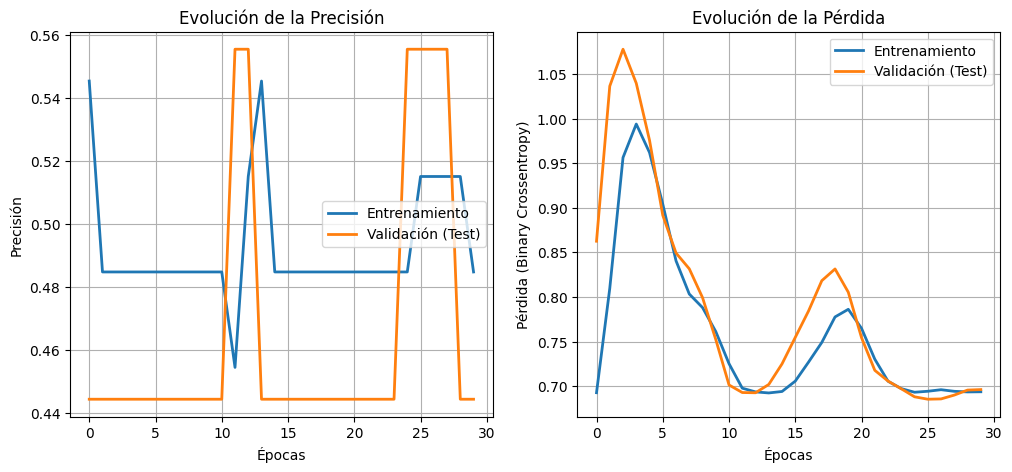

In [ ]:
# Extraer datos del historial
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Graficar
plt.figure(figsize=(12, 5))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(acc, label='Entrenamiento', linewidth=2)
plt.plot(val_acc, label='Validación (Test)', linewidth=2)
plt.title('Evolución de la Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(loss, label='Entrenamiento', linewidth=2)
plt.plot(val_loss, label='Validación (Test)', linewidth=2)
plt.title('Evolución de la Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
def prueba_ciega_profesor(ruta_audio_profesor, modelo):
    # 1. Aplicar mismo preprocesamiento
    caracteristicas = procesar_audio(ruta_audio_profesor)

    # 2. Ajustar dimensión para Keras (1 muestra, 13 coeficientes, 40 pasos)
    caracteristicas = caracteristicas.reshape(1, 13, 40)

    # 3. Predecir
    prediccion = modelo.predict(caracteristicas, verbose=0)[0][0]

    # 4. Simulación de salida (Umbral 0.5)
    print("-" * 40)
    if prediccion > 0.5:
        print(f"Probabilidad de ser 'Encender': {prediccion:.4f}")
        print("💡 SIMULACIÓN: LUZ ENCENDIDA")
    else:
        print(f"Probabilidad de ser 'Encender': {prediccion:.4f}")
        print("🌑 SIMULACIÓN: LUZ APAGADA")
    print("-" * 40)

# Uso (Descomenta la línea de abajo y pon la ruta del audio del profe el día de la entrega):
# prueba_ciega_profesor('/content/drive/MyDrive/Audios/audio_profe.wav', modelo)

**CONCLUSION**

En el desarrollo de este proyecto de "Luz Inteligente", logramos llevar a la práctica los conceptos de minería de datos. Un gran acierto fue trabajar en equipo. La parte de preparación de los datos fue un reto, pero resultó fundamental. Al usar librosa para extraer los MFCC, logramos transformar el sonido de nuestros comandos en datos numéricos procesables. También nos aseguramos de aplicar el padding y normalizar los valores para que el modelo recibiera la información de manera uniforme y sin problemas de tamaño.

Cuando pasamos a construir la red en Keras, nos dimos cuenta en la práctica de que hacer un modelo más grande y complejo no siempre da mejores resultados. Estuvimos haciendo varias pruebas experimentando con el número de capas ocultas y la cantidad de neuronas. Al ir revisando y comparando nuestras gráficas de pérdida y precisión, pudimos justificar y elegir la arquitectura más equilibrada: una que fuera lo suficientemente precisa para el proyecto, pero simple de procesar y sin caer en sobreajuste.

Gracias a la función sigmoide en nuestra capa de salida y al aplicar la lógica del umbral de 0.5, el sistema pudo clasificar correctamente si la luz debía encenderse o apagarse. Ver que el modelo logró generalizar y predecir de forma correcta un audio externo nos demostró que la red realmente aprendió a identificar los comandos y no solo memorizó nuestras grabaciones. Como equipo, nos llevamos una idea mucho más clara y práctica de todo lo que implica armar, ajustar y evaluar un modelo de machine learning desde cero.